In [156]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import ast

In [157]:
ALPHA = 1 / 0.086817
BETA = 1 / 0.050141

In [ ]:
def haversine(lon1, lat1, lon2, lat2):
    """Calculate distance (m) between two lat/lon pairs."""
    R = 6371000  # Earth radius in meters
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)

    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

def parse_geometry(geom_str):
    """Extract list of (lon, lat) from LINESTRING WKT."""
    coords_str = geom_str.strip().removeprefix("LINESTRING (").removesuffix(")")
    coords = [tuple(map(float, p.split())) for p in coords_str.split(", ")]
    return coords

def exp_penalty(s, alpha=20):
    """Map slope to 0–1 score where small slopes ~1 and big slopes ~0."""
    return math.exp(-alpha * abs(s))

def slope_metrics(elevations, coords):
    """Compute metrics for slope scoring."""
    slopes = []
    total_climb = 0.0
    total_descent = 0.0
    
    for i in range(len(coords)-1):
        d = haversine(coords[i][0], coords[i][1], coords[i+1][0], coords[i+1][1])
        dz = elevations[i+1] - elevations[i]
        if d > 0:
            slopes.append(math.atan(abs(dz / d)))
        if dz > 0:
            total_climb += dz
        elif dz < 0:
            total_descent += abs(dz)
    
    uphill = elevations[-1] - elevations[0] > 0
    if uphill:
        # Penalize extra climb over net height gain
        p_elevation = total_climb * 1.1 - (elevations[-1] - elevations[0])
    else:
        # Penalize extra descent over net height loss
        p_elevation = total_descent - abs(elevations[-1] - elevations[0])
    
    p_slope = max(slopes)    
    return p_elevation, p_slope

def slope_score(elevations, coords):
    """Calculate slope score for A→B and B→A."""
    def score_direction(elevs, crds):
        p_elevation, p_slope = slope_metrics(elevs, crds)
        score = 1 * ALPHA * math.sqrt(p_slope) + 0.05 * BETA * p_elevation #  - math.sqrt(p_elevation) 
        return score
    
    score_ab = score_direction(elevations, coords)
    score_ba = score_direction(list(reversed(elevations)), list(reversed(coords)))
    return score_ab, score_ba


In [159]:
df_all = pd.read_csv('../../routing/all_scored_edges_filtered_with_ai.csv')
# df_ac = pd.read_csv(r'C:\Users\vzhang\workplace\EquitableWalkability\STARSWalkability\accesscore\output\scored_edges_no_distance.csv')
df_ac = pd.read_csv('../output/accessibility_scored_edges_slope.csv')
df_all['elevations'] = df_ac['elevation_m_lmsl'].fillna(0)

C:\Users\vzhang\AppData\Local\Temp\ipykernel_32944\581717225.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv('../../routing/all_scored_edges_filtered_with_ai.csv')


In [160]:
slope_score_u_v = []
slope_score_v_u = []

pes = []
pss = []

for index, row in df_all.iterrows():
    elevations = ast.literal_eval(row['elevations'])
    coords = parse_geometry(row['geometry'])
    score_uv, score_vu = slope_score(elevations, coords)

    pe_uv, ps_uv = slope_metrics(elevations, coords)

    pes.append(pe_uv)
    pss.append(ps_uv)
    slope_score_u_v.append(score_uv)
    slope_score_v_u.append(score_vu)

In [161]:
slope_score_u_v = (pd.Series(slope_score_u_v) - min(slope_score_u_v)) / (max(slope_score_u_v) - min(slope_score_u_v))
slope_score_v_u = (pd.Series(slope_score_v_u) - min(slope_score_v_u)) / (max(slope_score_v_u) - min(slope_score_v_u))

In [162]:
df_all['slope_score_u_v'] = slope_score_u_v
df_all['slope_score_v_u'] = slope_score_v_u
# df_all.drop(columns=['elevation_m_lmsl'], inplace=True)
df_all.to_csv('../../routing/edges_1005.csv', index=False)

In [163]:
pes = pd.Series(pes)
pss = pd.Series(pss)
print(pes.describe())
print(pss.describe())

count    18972.000000
mean         0.086817
std          0.322798
min          0.000000
25%          0.000000
50%          0.008347
75%          0.063828
max         10.790638
dtype: float64
count    18972.000000
mean         0.050141
std          0.064581
min          0.000000
25%          0.016347
50%          0.032418
75%          0.058791
max          0.905733
dtype: float64


15.064305292009278


C:\Users\vzhang\AppData\Local\Temp\ipykernel_32944\3241543202.py:2: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv('../../routing/edges_1005.csv')


count    18972.000000
mean         0.961573
std          0.138382
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: slope_score_u_v, dtype: float64
   Unnamed: 0.3  Unnamed: 0.2  Unnamed: 0.1  Unnamed: 0         u  \
0             0             0             0           0  29938143   
1             1             1             1           1  53018668   
2             2             2             2           2  53018668   
3             3             3             3           3  53018668   
4             4             4             4           4  53025077   

             v  key                                             osm_id  \
0    321336630    0                                         1314104307   
1   5321393680    0                                          520907982   
2   3916774511    0                                          520907982   
3  10743226133    0  [1365680640, 1365680641, 1155217797, 551000076...   
4

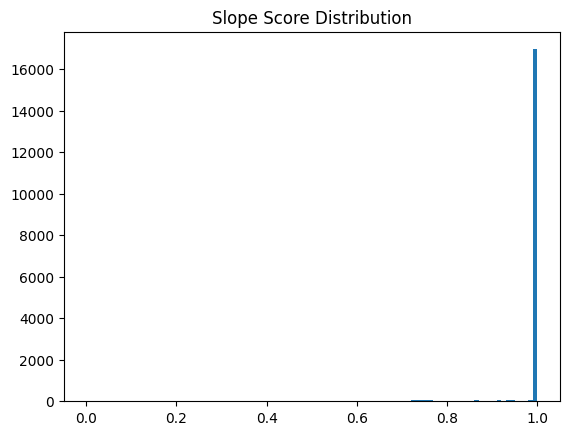

In [164]:
print((pss > 0.083).mean() * 100)
df_all = pd.read_csv('../../routing/edges_1005.csv')
print(df_all['slope_score_u_v'].describe())
print(df_all.head())
plt.hist(df_all['slope_score_u_v'], bins=100)
plt.title('Slope Score Distribution')
plt.show()

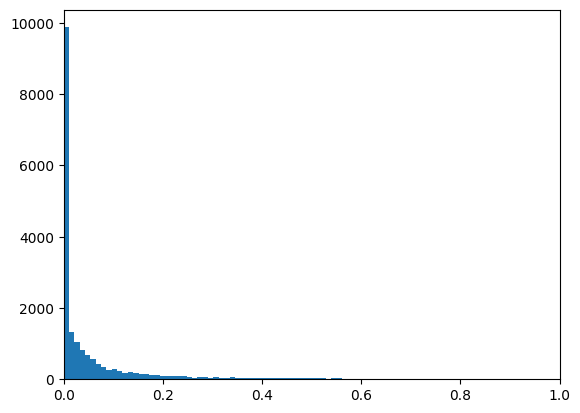

In [165]:
plt.hist(pes, bins=1000)
plt.xlim(0,1)
plt.show()

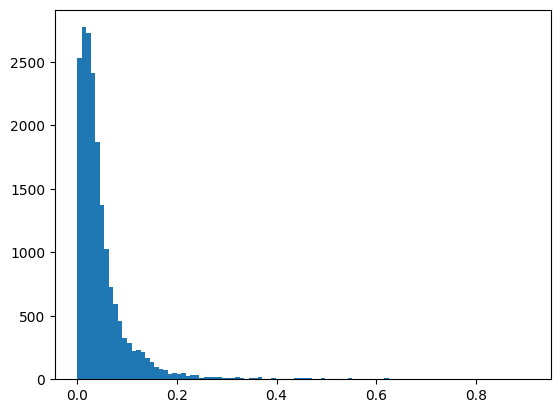

In [166]:
plt.hist(pss, bins=100)
plt.show()